# Problem

This notebook studies the 2D discrete Fourier transform of a grayscale image. The goal is to compute the image spectrum, visualize the magnitude response in normal and dB scales, shift the low-frequency components to the center, and compare the spectrum before and after a 90-degree image rotation.

The workflow is:

1. Load a grayscale image.
2. Compute its 2D Fourier transform.
3. Visualize the magnitude spectrum before and after centering.
4. Rotate the image by 90 degrees and analyze the transformed spectrum.
5. Compare the rotated-image spectrum with the rotated original spectrum.


In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


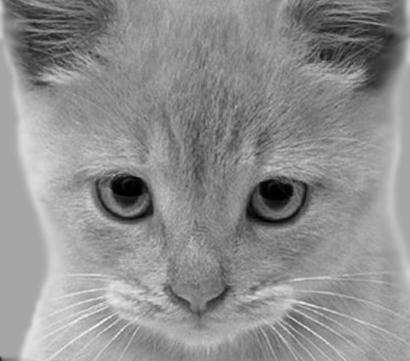

In [11]:
# Use the cat image as the input for the Fourier analysis.
source_image=Image.open('../data/cat_gray.jpg')
source_image

In [12]:
image_array=plt.imread('../data/cat_gray.jpg')

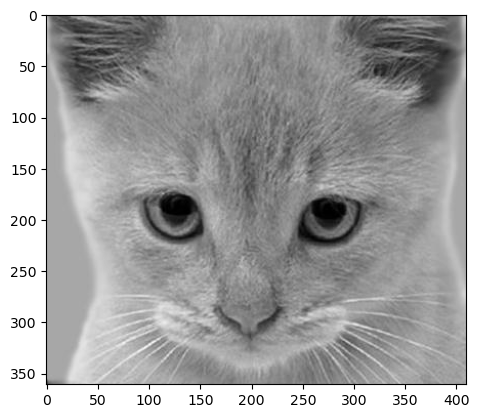

In [13]:
plt.imshow(image_array,cmap='gray')

## 2D Fourier Transform

The image is converted into a numeric array and transformed using the 2D FFT. This reveals how spatial frequency components contribute to the image structure.


In [14]:
def compute_2d_fft(signal):
     fourier_transform=np.fft.fft2(signal)
     return fourier_transform 
image_fft=compute_2d_fft(image_array)    
print(np.shape(image_fft))
print(np.shape(source_image))

(361, 410)
(361, 410)


## Magnitude Spectrum

The Fourier magnitude is plotted in both linear scale and dB scale. The dB plot makes weaker frequency components easier to inspect visually.


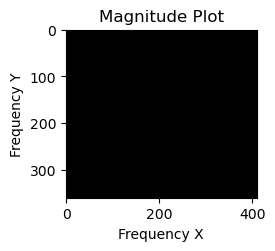

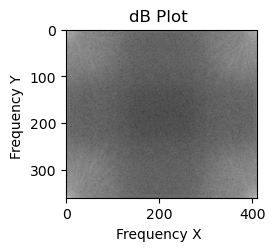

In [15]:
def plot_magnitude_and_db_spectrum(fourier_transform):
    magnitude=np.abs(fourier_transform)
    magnitude_db=20*np.log10(magnitude)
    plt.subplot(2,1,1)
    plt.title("Magnitude Plot")
    plt.imshow(magnitude, cmap='gray')
    plt.xlabel("Frequency X")
    plt.ylabel("Frequency Y")
    plt.show()

    plt.subplot(2,1,2)
    plt.title("dB Plot ")
    plt.imshow(magnitude_db, cmap='gray')
    plt.xlabel("Frequency X ")
    plt.ylabel("Frequency Y ")
    plt.show()

plot_magnitude_and_db_spectrum(image_fft)

## Spectrum Location

For the direct `np.fft.fft2` output, the DC component is located at the top-left corner of the spectrum. In image-frequency visualization, this often makes the plot harder to interpret because the low-frequency content is not centered.


## Centering the Spectrum

The spectrum can be shifted using `np.fft.fftshift` so that the low-frequency components move to the center of the 2D transform.


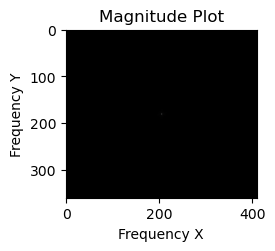

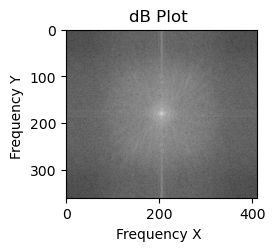

In [16]:
def shift_fft_to_center(fourier_transform):
    shifted_fourier_transform=np.fft.fftshift(fourier_transform)
    return shifted_fourier_transform

shifted_image_fft=shift_fft_to_center(image_fft)
plot_magnitude_and_db_spectrum(shifted_image_fft)

After applying the shift, the low-frequency components appear near the center and the higher-frequency components move toward the edges. This centered representation is easier to interpret visually.


## Rotation Experiment

The input image is rotated 90 degrees anticlockwise. The Fourier magnitude spectrum of the rotated image is then compared with the rotated spectrum of the original image.


(361, 410)
(361, 410)


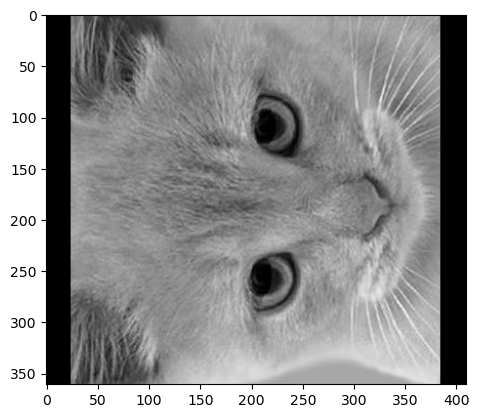

In [17]:
rotated_image=source_image.rotate(90)
plt.imshow(rotated_image,cmap='gray')
print( np.shape(rotated_image))
print( np.shape(source_image))

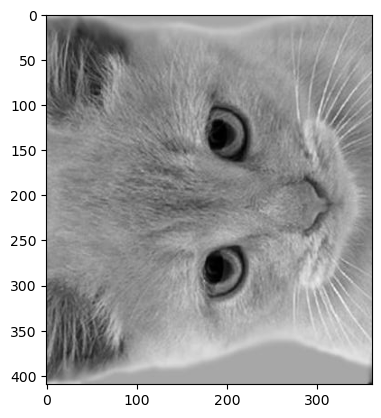

(410, 361)


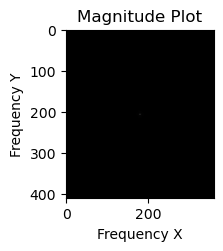

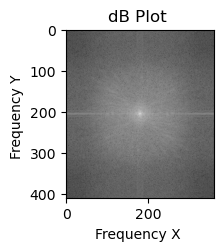

(410, 361)


In [18]:
rotated_image_array=np.rot90(image_array,k=1)
plt.imshow(rotated_image_array, cmap='gray')
plt.show()
print(np.shape(rotated_image_array))
rotated_image_fft=compute_2d_fft(np.array(rotated_image_array))
plot_magnitude_and_db_spectrum(shift_fft_to_center(rotated_image_fft))
print(np.shape(rotated_image_fft))

## Spectrum Comparison

The purpose of this comparison is to check whether rotating the image in the spatial domain produces a corresponding rotation in the frequency-domain magnitude spectrum.


The plots show that the Fourier magnitude spectrum of the 90-degree rotated image visually matches the 90-degree rotated spectrum of the original image. This supports the expected relationship between spatial rotation and frequency-domain rotation.


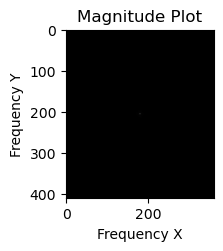

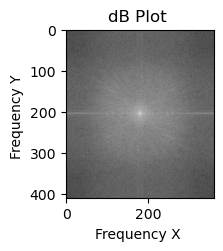

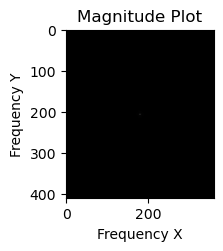

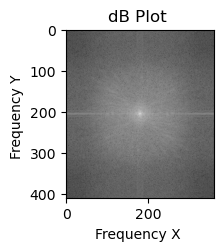

In [11]:
plot_magnitude_and_db_spectrum(np.rot90(shifted_image_fft,k=1))
plot_magnitude_and_db_spectrum(shift_fft_to_center(rotated_image_fft))

## Numerical Equivalence Check

The following cells check whether the two spectra are numerically close after rotation. This is included as an exploratory validation step rather than the main result.


The direct array comparison is difficult because rotation and centering can introduce shape and origin-alignment differences. Therefore, the visual comparison is more useful for this notebook's main observation.


In [12]:
def compare_magnitude_arrays(array1 , array2):
   
  shape=np.shape(array1)
  x=np.array([1,0])
  y=np.array([0,1])
  check=True

  if np.isclose(np.abs(array1),np.abs(array2), rtol=1e-5, atol=1e-8, equal_nan=False).all():
    check=True
  else:  
     check=False
  if check==False: 
    print("My eyes are poor")
  else:
    print("My eyes are healthy")

In [13]:
# Direct numerical equality is harder here because image rotation changes array orientation and origin alignment.
# The following checks compare rotated frequency-domain arrays as an exploratory validation step.

In [14]:
rotated_original_fft=np.rot90(image_fft,k=1)
print(np.shape(rotated_original_fft))
print(np.shape(rotated_image_fft))
print(np.shape(image_fft))
compare_magnitude_arrays(rotated_original_fft,rotated_image_fft)

(410, 361)
(410, 361)
(361, 410)
My eyes are poor


In [15]:
# The unshifted FFT is centered at the corner, so direct rotation is not the clearest comparison.
# The centered spectrum gives a more interpretable visual comparison.

In [16]:
compare_magnitude_arrays(np.rot90(shifted_image_fft,k=1),shift_fft_to_center(rotated_image_fft))

My eyes are poor


## Conclusion

This notebook demonstrates how the 2D Fourier transform represents image-frequency content. The direct FFT places the DC component at the corner, while `fftshift` moves the low-frequency content to the center for clearer visualization. Rotating the image in the spatial domain produces a corresponding rotation in the Fourier magnitude spectrum, which is visible from the plotted comparisons.
